------Class Distribution------
crop: 75
wild: 75
------Cross-Validation with GridSearch------
Best C: 10
Best CV F1 Score: 0.5009
Accuracy: 0.6
------Classification Report------
              precision    recall  f1-score   support

        crop       0.67      0.40      0.50        15
        wild       0.57      0.80      0.67        15

    accuracy                           0.60        30
   macro avg       0.62      0.60      0.58        30
weighted avg       0.62      0.60      0.58        30

------Confusion Matrix------


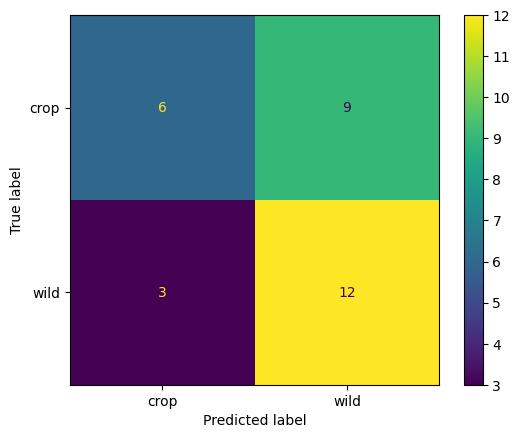

------Misclassified Sequence IDs------
NC_007609_WILD_(+1)
NC_010832_CROP_(+1)
NC_009041_WILD_(+1)
NC_002198_CROP_(+1)
NC_014546_WILD_(+1)
OR879089_WILD_(+1)
NC_001977_WILD_(+1)
NC_023014_CROP_(+1)
NC_010178_WILD_(+1)
NC_034208_CROP_(+1)
NC_022894_WILD_(+1)
NC_003633_CROP_(+1)


In [1]:
# Single Fit

# === Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# === Parameters ===
CSV_FILE = "virus_data.csv"  # Must include: id, type, family, length, sequence
KMER_SIZES = []
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_SPLITS = 5

# === K-mer Extraction ===
def get_kmers(sequence, k):
    sequence = sequence.upper()
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)]) if len(sequence) >= k else ''

# === Load and Preprocess CSV ===
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACDEFGHIKLMNPQRSTVWY]', '', regex=True)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['type'])

    return df, y, label_encoder

# === Grid Search for a Given K-mer Size ===
def grid_search_svm(kmers, y):
    print("Running Grid Search...")
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer()),
        ('svm', SVC(kernel='rbf', decision_function_shape='ovr'))
    ])

    param_grid = {
        'svm__C': [0.1]
        'svm__gamma': ['scale']
    }

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid.fit(kmers, y)
    return grid.best_estimator_, grid.best_score_, grid.best_params_

# === Evaluate Final Model ===
def evaluate(model, kmers_test, y_test, label_encoder):
    y_pred = model.predict(kmers_test)

    print("\n=== Test Set Evaluation ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    return y_pred

# === Main Routine ===
def main():
    df, y, le = load_data(CSV_FILE)

    best_overall_score = -1
    best_model = None
    best_kmer_size = None

    for k in KMER_SIZES:
        print(f"\n=== Evaluating k-mer size {k} ===")
        df['kmers'] = df['sequence'].apply(lambda seq: get_kmers(seq, k))
        filtered = df[df['kmers'].str.len() > 0].copy()
        kmers = filtered['kmers']
        ids = filtered['id']
        y_filtered = le.transform(filtered['type'])

        # Split
        kmers_train, kmers_test, y_train, y_test, ids_train, ids_test = train_test_split(
            kmers, y_filtered, filtered['id'], test_size=TEST_SIZE, stratify=y_filtered, random_state=RANDOM_STATE
        )

        model, score, params = grid_search_svm(kmers_train, y_train)
        print(f"Best F1 (macro): {score:.4f} | Params: {params}")

        if score > best_overall_score:
            best_overall_score = score
            best_model = model
            best_kmer_size = k
            final_data = (kmers_train, kmers_test, y_train, y_test, ids_test)

    print(f"\n=== Best Overall Model: k-mer = {best_kmer_size} | F1 = {best_overall_score:.4f} ===")
    kmers_train, kmers_test, y_train, y_test, ids_test = final_data

    y_pred = evaluate(best_model, kmers_test, y_test, le)

    print("\n=== Misclassified Sequence IDs ===")
    for i, (true, pred) in enumerate(zip(y_test, y_pred)):
        if true != pred:
            print(ids_test.iloc[i])

if __name__ == "__main__":
    main()

------Class Distribution------
crop: 75
wild: 75
------Cross-Validation with GridSearch------
Best C: 10
Best CV F1 Score: 0.5009
Accuracy: 0.6
------Classification Report------
              precision    recall  f1-score   support

        crop       0.67      0.40      0.50        15
        wild       0.57      0.80      0.67        15

    accuracy                           0.60        30
   macro avg       0.62      0.60      0.58        30
weighted avg       0.62      0.60      0.58        30

------Confusion Matrix------


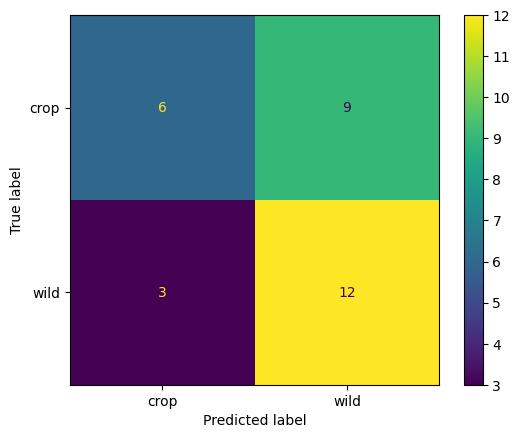

------Misclassified Sequence IDs------
NC_007609_WILD_(+1)
NC_010832_CROP_(+1)
NC_009041_WILD_(+1)
NC_002198_CROP_(+1)
NC_014546_WILD_(+1)
OR879089_WILD_(+1)
NC_001977_WILD_(+1)
NC_023014_CROP_(+1)
NC_010178_WILD_(+1)
NC_034208_CROP_(+1)
NC_022894_WILD_(+1)
NC_003633_CROP_(+1)


In [1]:
# Hyperparameter tuning

# === Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# === Parameters ===
CSV_FILE = "virus_data.csv"  # Must include: id, type, family, length, sequence
KMER_SIZES = [3, 5, 7]
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_SPLITS = 5

# === K-mer Extraction ===
def get_kmers(sequence, k):
    sequence = sequence.upper()
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)]) if len(sequence) >= k else ''

# === Load and Preprocess CSV ===
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACDEFGHIKLMNPQRSTVWY]', '', regex=True)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['type'])

    return df, y, label_encoder

# === Grid Search for a Given K-mer Size ===
def grid_search_svm(kmers, y):
    print("Running Grid Search...")
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer()),
        ('svm', SVC(kernel='rbf', decision_function_shape='ovr'))
    ])

    param_grid = {
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 0.01, 0.001]
    }

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid.fit(kmers, y)
    return grid.best_estimator_, grid.best_score_, grid.best_params_

# === Evaluate Final Model ===
def evaluate(model, kmers_test, y_test, label_encoder):
    y_pred = model.predict(kmers_test)

    print("\n=== Test Set Evaluation ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    return y_pred

# === Main Routine ===
def main():
    df, y, le = load_data(CSV_FILE)

    best_overall_score = -1
    best_model = None
    best_kmer_size = None

    for k in KMER_SIZES:
        print(f"\n=== Evaluating k-mer size {k} ===")
        df['kmers'] = df['sequence'].apply(lambda seq: get_kmers(seq, k))
        filtered = df[df['kmers'].str.len() > 0].copy()
        kmers = filtered['kmers']
        ids = filtered['id']
        y_filtered = le.transform(filtered['type'])

        # Split
        kmers_train, kmers_test, y_train, y_test, ids_train, ids_test = train_test_split(
            kmers, y_filtered, filtered['id'], test_size=TEST_SIZE, stratify=y_filtered, random_state=RANDOM_STATE
        )

        model, score, params = grid_search_svm(kmers_train, y_train)
        print(f"Best F1 (macro): {score:.4f} | Params: {params}")

        if score > best_overall_score:
            best_overall_score = score
            best_model = model
            best_kmer_size = k
            final_data = (kmers_train, kmers_test, y_train, y_test, ids_test)

    print(f"\n=== Best Overall Model: k-mer = {best_kmer_size} | F1 = {best_overall_score:.4f} ===")
    kmers_train, kmers_test, y_train, y_test, ids_test = final_data

    y_pred = evaluate(best_model, kmers_test, y_test, le)

    print("\n=== Misclassified Sequence IDs ===")
    for i, (true, pred) in enumerate(zip(y_test, y_pred)):
        if true != pred:
            print(ids_test.iloc[i])

if __name__ == "__main__":
    main()